# JAX Reference Notebook

Let's build computronium in JAX, as god intended. 

This notebook is my notes on JAX, focusing on the departures from PyTorch. 

In [2]:
import jax
import jax.numpy as jnp
from jax import random, jit, vmap, grad


import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

## JAX Tensors and Gradients




In [2]:
# generate an array of [3, 1, 2] in Jax, put on GPU, check datatype
x = jnp.array([3, 1, 4], dtype=jnp.float16)
y = jnp.array([1, 5, 9], dtype=jnp.float16)
print(x)
print(x.dtype)

[3. 1. 4.]
float16


In [3]:
x @ jnp.array([y], dtype=jnp.float16).T
print("y shape: ", jnp.array([y]).shape)

A = jnp.eye(3, dtype=jnp.float16)

print(A @ x)

y shape:  (1, 3)
[3. 1. 4.]


In [4]:
matrix = jnp.array([[1, 2, 3],
                    [4, 5, 6],
                    [7, 8, 9]])
vector = jnp.array([7, 8, 9])

print("Matrix shape: ", matrix.shape)
print("Vector shape: ", vector.shape)

result1 = jnp.dot(matrix, vector)  # Output: [50, 122]
result2 = jnp.dot(vector, matrix)  # Output: [30, 36, 42]
print(result1)
print(result2)

Matrix shape:  (3, 3)
Vector shape:  (3,)
[ 50 122 194]
[102 126 150]


In [5]:
row_vector = jnp.array([1, 2, 3]).reshape(1, -1)  # Reshapes to a row vector
column_vector = jnp.array([1, 2, 3])[:, jnp.newaxis]  # Adds a new axis to create a column vector

print("Row vector shape: ", row_vector.shape)
print(row_vector)
print("\nColumn vector shape: ", column_vector.shape)
print(column_vector)

Row vector shape:  (1, 3)
[[1 2 3]]

Column vector shape:  (3, 1)
[[1]
 [2]
 [3]]


## Looking at the Computational Graph + XLA Code

XLA is the cross-platform intermediate language JAX compiles to so it can be run
on any hardware that does XLA (kinda like A10/CUBLAS/CUDA/BLAS on other
systems). 

In [6]:

def linear_regression(X, y):
    w = jnp.zeros(X.shape[1])
    
    @jax.jit
    def train_step(w, X, y):
        y_pred = jnp.dot(X, w)
        loss = jnp.mean((y_pred - y) ** 2)
        grads = jax.grad(lambda w: jnp.mean((jnp.dot(X, w) - y) ** 2))(w)
        w -= 0.01 * grads
        return w, loss
    
    for _ in tqdm(range(2)):
        w, loss = train_step(w, X, y)
    
    return w

# Generate random data
key = jax.random.PRNGKey(0)
X = jax.random.normal(key, (100, 3))
y = jax.random.normal(key, (100,))

# Train the model
w = linear_regression(X, y)

# Inspect the XLA-compiled code
print("XLA-compiled code:")
# print(jax.xla_computation(linear_regression)(X, y).as_hlo_text())

# Inspect the computational graph
print("\n\n\nComputational graph:")
# print(jax.make_jaxpr(linear_regression)(X, y))

100%|██████████| 2/2 [00:00<00:00, 32.10it/s]

XLA-compiled code:



Computational graph:


## Selecting Device (CPU, GPU, TPU, NPU, etc.)


In [7]:
devices = jax.devices()
print(devices)

gpu_device = jax.devices("gpu")[0]
cpu_device = jax.devices("cpu")[0]
print("GPU Device: ", gpu_device)
print("CPU Device: ", cpu_device)

data = jax.device_put(jnp.array([1, 2, 3.03]), gpu_device)
print(data)
print("data.devices(): ", data.devices())
print("Type of data.devices(): ", type(data.devices()))

[cuda(id=0)]
GPU Device:  cuda:0
CPU Device:  TFRT_CPU_0
[1.   2.   3.03]
data.devices():  {cuda(id=0)}
Type of data.devices():  <class 'set'>


## Simple `vmap()` Example

My favourite thing about JAX is that you can turn your functions into parallelized, efficient batched functions by just calling `batched_f = vmap(f)`. As if that weren't enough, it's often more efficient than writing your own batched code! So, imo, this is a win-win and we should use this all the time so that we never have to re-write our hacky non-batched code as batched. 

In this example, we will define an MLP class where we supply the 

## Deeply Understanding Convolutions

In this example, we train one convolutional layer to match the input-output map 
of another. 
 1. Define convolution class with JAX -- you will need to cache both to disk and 
 be able to reload them for the evals! It should take in a 3-dim tensor (make sure 
 to notate the order of the bitmap dims for x, y, state using standard convention for 
 images x, y, RGB order in JAX). The convolution layer classes should output a tensor 
 of the same shape as the original too. 
 2. Define the loss function. Given two bitmaps -- the ground truth output and
 the "student" convolution layer output -- compute the $\ell_2$ loss. 
 3. Set up the optimizer (SGD and Adam) -- start with a simple SGD optimizer by
 hand, then show how you would use the pre-built Adam optimizer. 

**Axis Conventions**: 
By default, in the lax.conv_general_dilated uses `(input='NCHW', kernel='OIHW',
output='NCHW')) where N is the batch, C is the input channel dim, HW are
height/width, O is the output channel, I is the input channel. 

Let's stick with that. To override it, we can supply kwarg
`dimension_numbers=('NCHW', 'OIHW', 'NCHW')` corresponding to (lhs/input,
rhs/kernel, output) to the lax.conv_general_dilated().

Window strides kwarg to lax.conv_general_dilated() are given in terms of the 
kernel (rhs) element ordering. 


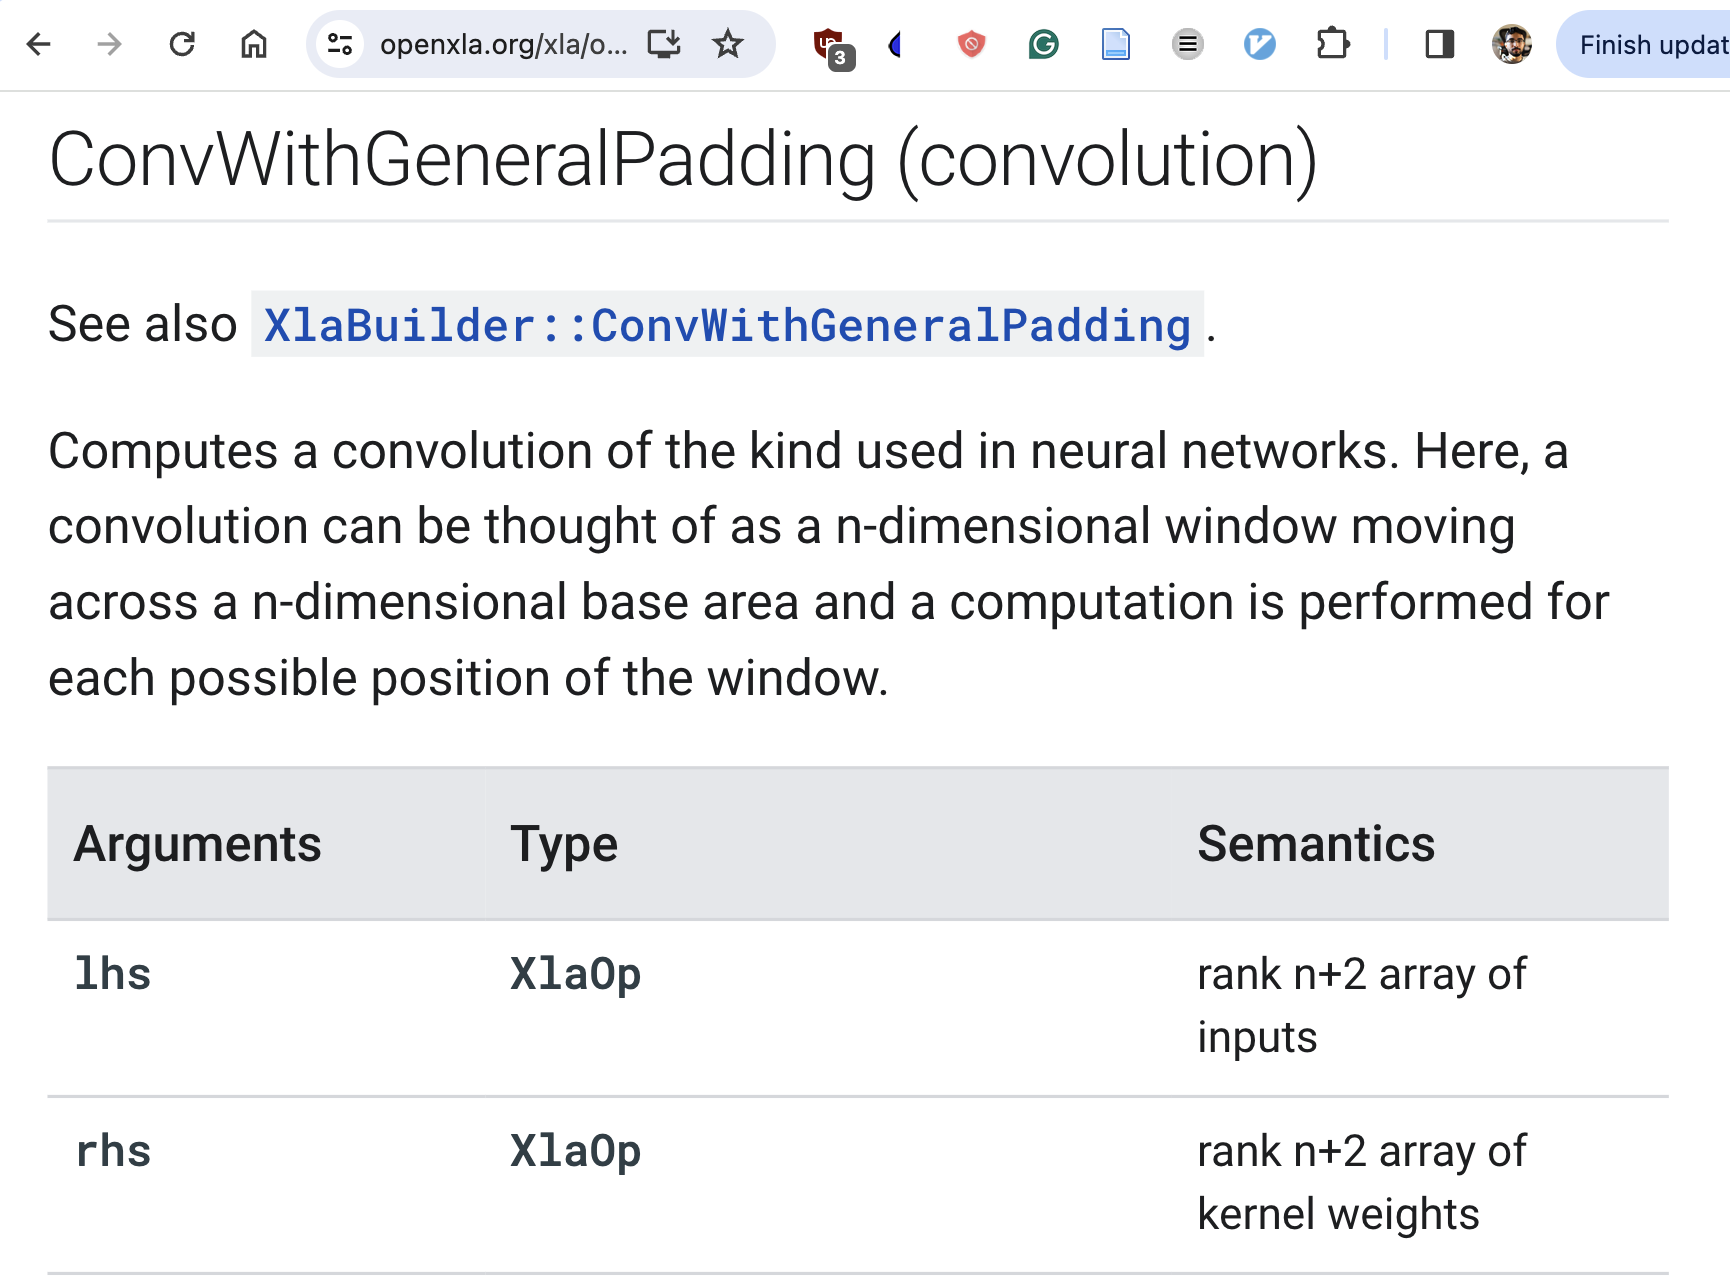


In [3]:
import jax
import jax.numpy as jnp

def conv_net(params, x):
    conv1_params = params
    
    x = jax.lax.conv_general_dilated(x, 
                                     conv1_params['weights'], 
                                     window_strides=(1, 1),
                                     padding='SAME')
    x += conv1_params['bias']
    x = jax.nn.sigmoid(x)
    return x

def init_params(rng_key, d_in=3, d_out=3, kernel_size=5):
    conv1_key, conv2_key, fc_key = jax.random.split(rng_key, 3)

    conv1_params = {
        # uniform 
        'weights': jax.random.uniform(conv1_key, 
                                      (d_out, d_in, kernel_size, kernel_size), 
                                      minval=-1, 
                                      maxval=1) * (jnp.sqrt(6/(3+3))), # 3 output channels, 3 input channels, 3x3 kernel
        'bias': jnp.zeros((1,3,1,1)) # add to (batch, channel, h, w) state tensor. 
    }
    
    return (conv1_params)

params_student = init_params(jax.random.PRNGKey(0))
params_teacher = init_params(jax.random.PRNGKey(1))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


X_train shape:  (100, 3, 18, 18)
y_train shape:  (100, 3, 18, 18)


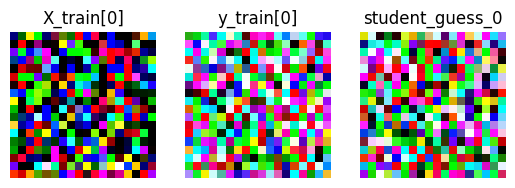

In [9]:
# training loop to match student, teacher nnets 
# create dataset with teacher first 
num_train_examples = 100
num_test_examples = 100
input_shape = (3, 18, 18)

X_train = jax.random.normal(jax.random.PRNGKey(0), (num_train_examples, *input_shape))
y_train = conv_net(params_teacher, X_train)

X_test = jax.random.normal(jax.random.PRNGKey(1), (num_test_examples, *input_shape))
y_test = conv_net(params_teacher, X_test)

student_guess_0 = conv_net(params_student, X_test[0:1])

# print overview of dataset, visualize an x and y bitmap in rgb
print("X_train shape: ", X_train.shape)
print("y_train shape: ", y_train.shape)

# visualize an x and y bitmap in rgb, use matplotlib
X0_ex = X_train[0].transpose(1, 2, 0)

# make a side-by-side graph
fig, axs = plt.subplots(1, 3)
axs[0].imshow(X0_ex)
axs[0].set_title('X_train[0]')
axs[0].axis('off')
axs[1].imshow(y_train[0].transpose(1, 2, 0))
axs[1].set_title('y_train[0]')
axs[1].axis('off')
axs[2].imshow(student_guess_0[0].transpose(1, 2, 0))
axs[2].set_title('student_guess_0')
axs[2].axis('off')
plt.show()


In [10]:
import math
# loss function -- mean squared error
def loss_fn(params, X, y):
    y_pred = conv_net(params, X)
    return jnp.mean((y_pred - y) ** 2)

# given a params:tuple[dict], grads:tuple[dict], lr:float, return updated params -- thanks jax!
def update_params(params, grads, lr):
    return jax.tree.map(lambda p, g: p - lr * g, params, grads)

# grad function
grad_fn = jax.grad(loss_fn)

# training loop
lr = 0.1
num_epochs = 1000
eval_frac = 1/13

batch_size = 300

train_losses = []
test_losses = []
for epoch in range(num_epochs):

    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]
        grads = grad_fn(params_student, X_batch, y_batch)
        params_student = update_params(params_student, grads, lr)

    train_loss = loss_fn(params_student, X_train, y_train)
    train_losses.append(train_loss)
    if (epoch // math.ceil(num_epochs * eval_frac)) != ((epoch-1) // math.ceil(num_epochs * eval_frac)):
        test_loss = loss_fn(params_student, X_test, y_test)
        test_losses.append(test_loss)
        print(f'Epoch {epoch}, Train Loss: {train_loss}, Test Loss: {test_loss}')


Epoch 0, Train Loss: 3.081258910242468e-05, Test Loss: 3.111574551439844e-05
Epoch 77, Train Loss: 3.057208959944546e-05, Test Loss: 3.088621815550141e-05
Epoch 154, Train Loss: 3.0335462724906392e-05, Test Loss: 3.065949567826465e-05
Epoch 231, Train Loss: 3.0102413802524097e-05, Test Loss: 3.0435436201514676e-05
Epoch 308, Train Loss: 2.987279003718868e-05, Test Loss: 3.021389784407802e-05
Epoch 385, Train Loss: 2.9645947506651282e-05, Test Loss: 2.9994283977430314e-05
Epoch 462, Train Loss: 2.9421931685646996e-05, Test Loss: 2.977674921567086e-05
Epoch 539, Train Loss: 2.9200806238804944e-05, Test Loss: 2.9561475457740016e-05
Epoch 616, Train Loss: 2.898200364143122e-05, Test Loss: 2.9347864256124012e-05
Epoch 693, Train Loss: 2.8765878596459515e-05, Test Loss: 2.9136266675777733e-05
Epoch 770, Train Loss: 2.855214370356407e-05, Test Loss: 2.8926639060955495e-05
Epoch 847, Train Loss: 2.8340511562419124e-05, Test Loss: 2.8718572139041498e-05
Epoch 924, Train Loss: 2.8131182261859067

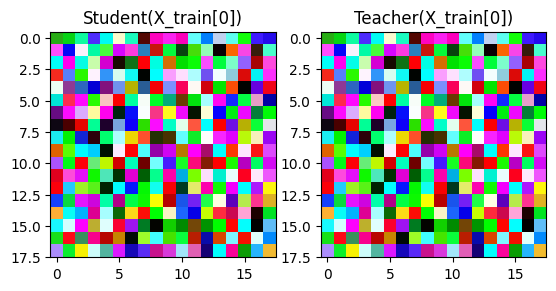

In [11]:
# plot the training and test loss next to each other
student_0_y = conv_net(params_student, X_train[0:1])
teacher_0_y = conv_net(params_teacher, X_train[0:1])

fig, axs = plt.subplots(1, 2)
axs[0].imshow(student_0_y[0].transpose(1, 2, 0))
axs[0].set_title('Student(X_train[0])')

axs[1].imshow(teacher_0_y[0].transpose(1, 2, 0))
axs[1].set_title('Teacher(X_train[0])')
plt.show()